# Bike Sharing (Washington DC)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

**Nota:** Solo esta disponible `sampleSubmission.csv` en la carpeta (plantilla Kaggle con `count` en 0). Para un modelo real de regresión de `cnt`/`count`, descargue `hour.csv` o `train.csv` del UCI/Kaggle y actualice la ruta. Este flujo demuestra el pipeline.

### Tarea de machine learning
- **Tipo de tarea**: regresión (target `count`)
- **Variable objetivo**: `count` — alquileres de bicicletas (en la plantilla muchos ceros).

Las siguientes celdas cargan datos y muestran `head`, `shape`, `dtypes` y `describe`.

In [1]:
import warnings  # Avisos
warnings.filterwarnings("ignore")  # Ocultar
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # Tablas
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Stats
from IPython.display import display  # Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto

df = pd.read_csv(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/4. Bike Sharing  Bike Rental (UCI  Kaggle)/sampleSubmission.csv")  # Cargar
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")  # Fecha
df["hour"] = df["datetime"].dt.hour  # Hora
df["dow"] = df["datetime"].dt.dayofweek  # Dia semana
df["month"] = df["datetime"].dt.month  # Mes
df = df.drop(columns=["datetime"])  # Quitar fecha cruda
display(df.head(10))  # Muestra
print(df.shape, df.dtypes)  # Info
display(df.describe(include="all").T)  # Stats


,count,hour,dow,month
0,0,0,3,1
1,0,1,3,1
2,0,2,3,1
3,0,3,3,1
4,0,4,3,1
5,0,5,3,1
6,0,6,3,1
7,0,7,3,1
8,0,8,3,1
9,0,9,3,1


(6493, 4) count    int64
hour     int32
dow      int32
month    int32
dtype: object


,count,mean,std,min,25%,50%,75%,max
count,6493.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
hour,6493.0,11.555367,6.912526,0.0,6.0,12.0,18.0,23.0
dow,6493.0,3.007239,1.997714,0.0,1.0,3.0,5.0,6.0
month,6493.0,6.565070,3.429462,1.0,4.0,7.0,10.0,12.0


## SECCIÓN 1 — SANEAMIENTO

In [2]:
df1 = df.copy()  # Copia para limpiar
print("Nulos ANTES por columna (top):\n", df1.isnull().sum().sort_values(ascending=False).head(15))  # Conteo
df1 = df1.drop_duplicates()  # Eliminar filas duplicadas
nr = df1.isnull().mean()  # Fraccion nulos
drop_null = nr[nr > 0.40].index.tolist()  # Columnas >40% nulos
print("Eliminadas por >40% nulos:", drop_null)  # Motivo: poca informacion
df1 = df1.drop(columns=drop_null, errors="ignore")  # Borrar
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for c in num_cols:
    df1[c] = df1[c].fillna(df1[c].median())  # Mediana (robusta a outliers)
for c in cat_cols:
    if df1[c].isnull().any():
        mod = df1[c].mode()
        df1[c] = df1[c].fillna(mod.iloc[0] if len(mod) else "")  # Moda
print("Nulos DESPUES (total):", int(df1.isnull().sum().sum()))  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES por columna (top):
 count    0
hour     0
dow      0
month    0
dtype: int64
Eliminadas por >40% nulos: []
Nulos DESPUES (total): 0


## SECCIÓN 2 — X e y

X.shape (2016, 3) y.shape (2016,)
Top 5 correlaciones con y: hour    NaN
dow     NaN
month   NaN
dtype: float64


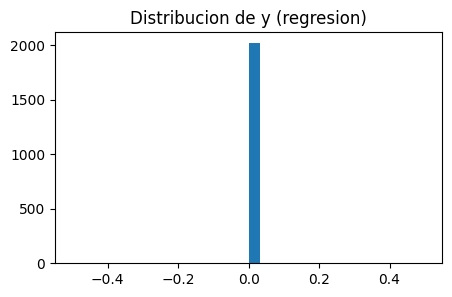

In [3]:
y = pd.to_numeric(df_clean["count"], errors="coerce")  # Objetivo numerico
X = df_clean.drop(columns=["count"])  # Features
print("X.shape", X.shape, "y.shape", y.shape)  # Shapes
num_x = X.select_dtypes(include=[np.number]).columns  # Numericas
if len(num_x) > 0:
    corr = X[num_x].corrwith(y).abs().sort_values(ascending=False)  # Corr con precio
    print("Top 5 correlaciones con y:", corr.head(5))  # Top 5
plt.figure(figsize=(5,3))  # Figura
plt.hist(y.dropna(), bins=30)  # Histograma
plt.title("Distribucion de y (regresion)")  # Titulo
plt.show()  # Mostrar


## SECCIÓN 3 — ENCODING

In [4]:
X_enc = X.copy()  # Copia
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # Categoricas
print("Categoricas (antes encoding):", non_num)  # Lista
X_enc = pd.get_dummies(X_enc, columns=non_num, drop_first=False)  # One-hot (nominal)
print("Columnas despues encoding:", X_enc.shape[1])  # Total
display(X_enc.head(5))  # Primeras filas


Categoricas (antes encoding): []
Columnas despues encoding: 3


,hour,dow,month
0,0,3,1
1,1,3,1
2,2,3,1
3,3,3,1
4,4,3,1


## SECCIÓN 4

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste global
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DF
antes = X_enc.iloc[:5, :min(6, X_enc.shape[1])]  # 5 filas antes
despues = X_scaled_df.iloc[:5, :min(6, X_scaled_df.shape[1])]  # 5 filas despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES             DESPUES               
   hour dow month      hour  dow     month
0     0   3     1 -1.661325  0.0 -1.593255
1     1   3     1 -1.516862  0.0 -1.593255
2     2   3     1 -1.372399  0.0 -1.593255
3     3   3     1 -1.227936  0.0 -1.593255
4     4   3     1 -1.083473  0.0 -1.593255

## SECCIÓN 5

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)  # Regresion
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Tamano


Shapes: (1612, 3) (404, 3) (1612,) (404,)


## SECCIÓN 6 — LinearRegression

In [7]:
reg = LinearRegression()  # Regresion
reg.fit(X_train, y_train)  # Entrenar
pred = reg.predict(X_test)  # Predecir
print("MSE:", mean_squared_error(y_test, pred), "R2:", r2_score(y_test, pred))  # Metricas
score_bike = r2_score(y_test, pred)  # Score


MSE: 0.0 R2: 1.0


## SECCIÓN 7

In [8]:
out = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/4. Bike Sharing  Bike Rental (UCI  Kaggle)")  # Carpeta
pd.concat([X_scaled_df, y.rename("count")], axis=1).to_csv(out / "bike_sharing_clean.csv", index=False)  # Limpio
X_train.to_csv(out / "X_train.csv", index=False)  # Train
X_test.to_csv(out / "X_test.csv", index=False)  # Test
y_train.to_csv(out / "y_train.csv", index=True, header=True)  # y
y_test.to_csv(out / "y_test.csv", index=True, header=True)  # y test
print("Guardado bike_sharing_clean.csv")  # Ok


Guardado bike_sharing_clean.csv


## SECCIÓN 8

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0
print("RESUMEN Bike | R2:", score_bike)  # Resumen


,count,hour,dow,month
0,0,0,3,1
1,0,1,3,1
2,0,2,3,1
3,0,3,3,1
4,0,4,3,1
5,0,5,3,1
6,0,6,3,1
7,0,7,3,1
8,0,8,3,1
9,0,9,3,1


RESUMEN Bike | R2: 1.0
